In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [16]:
llm_results = pd.read_csv(
    "../results/norm_simu_times/llm_normalized_stime_results.tsv", sep="\t"
)
regex_results = pd.read_csv(
    "../results/norm_simu_times/regex_normalized_stime_results.tsv", sep="\t"
)

In [17]:
llm_results.head(5)

,STIME,LLM_value,LLM_unit
0,0.5 μs,0.5,μs
1,1 microsecond,1.0,μs
2,1 microsecond,1.0,μs
3,1 microsecond,1.0,μs
4,1 microsecond,1.0,μs


In [18]:
valid_ns_llm = llm_results["LLM_value"].dropna().tolist()
valid_ns_reg = regex_results["regex_value"].dropna().tolist()


In [19]:
len(valid_ns_llm)

111

In [20]:
len(valid_ns_reg)

88

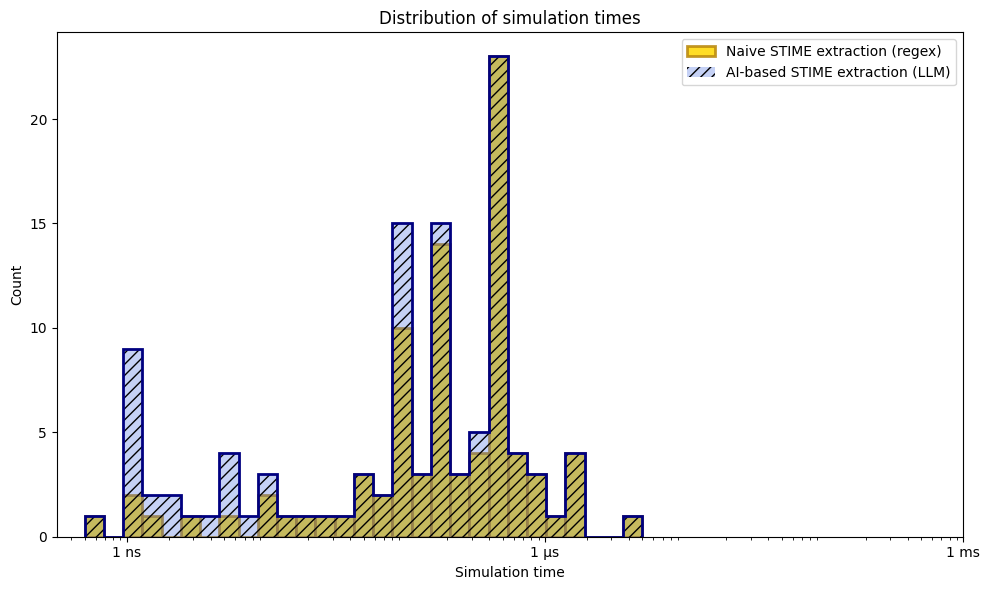

In [21]:
global_min = min(min(valid_ns_llm), min(valid_ns_reg))
global_max = max(max(valid_ns_llm), max(valid_ns_reg))
shared_bins = np.logspace(np.log10(global_min), np.log10(global_max), 30)

x_ticks = [1e0, 1e3, 1e6]
x_labels = ["1 ns", "1 μs", "1 ms"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    valid_ns_reg,
    bins=shared_bins,
    color="gold",
    edgecolor="darkgoldenrod",
    alpha=0.85,
    linewidth=2,
    label="Naive STIME extraction (regex)",
)
ax.hist(
    valid_ns_llm,
    bins=shared_bins,
    color="royalblue",
    alpha=0.30,
    linewidth=2,
    hatch="///",
    label="AI-based STIME extraction (LLM)",
)
ax.hist(
    valid_ns_llm,
    bins=shared_bins,
    histtype="step",
    edgecolor="navy",
    linewidth=2.0,
)


ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Simulation time")
ax.set_ylabel("Count")
ax.set_title("Distribution of simulation times")
ax.legend()
plt.tight_layout()
plt.show()